# PROYECTO MÓDULO 5 CIENCIA DE DATOS

## Listado de Librerias utilizadas

In [2]:
# Proyecto Módulo 5 - Curso Ciencia de Dato -
# Reinaldo Elgueta A.
# Entrega el día 27 de febrero 2026

# Objetivo principal:Desarrollar una investigación estadística completa siguiendo el método científico,
# identificando hipótesis relevantes, midiendo variables clave y realizando
# inferencias válidas sobre los hábitos saludables de la población objetivo

# Librerías
import pandas as pd               #Lección 2 en adelante
import numpy as np                #Lección 2 en adelante
import matplotlib.pyplot as plt   #Lección 3
import seaborn as sns             #Lección 3
import matplotlib.pyplot as plt   #Lección 4
import seaborn as sns             #Lección 4
from scipy.stats import norm      #Lección 4
import scipy.stats as stats       #Lección 5


In [ ]:
#===============================================================================
#                     LECCIÓN 1 - DESARROLLADO EN DOCUMENTO PDF
#===============================================================================

##LECCIÓN 2: Probabilidad y estadística



1.   Objetivo:

  Modelar los eventos estadísticos, establecer el espacio muestral y
diseñar el plan de muestreo.

2.   Tareas a desarrollar:



*   Definir eventos aleatorios y su representación con árboles de
probabilidad
*   Explicar el tipo de muestreo a aplicar (aleatorio simple, estratificado,
etc.)
*   Simular el diseño muestral (con mínimo 100 registros)
*   Calcular probabilidades básicas de eventos (intersección, unión,
complementarios)

In [3]:
#===============================================================================
#                                  LECCIÓN 2
#===============================================================================
# Configuración de aleatoriedad
np.random.seed(42)
n_estudiantes = 100

# Generación de variables
data = {
    'ID_Estudiante': range(1, n_estudiantes + 1),
    'Edad': np.random.randint(18, 30, n_estudiantes),
    'Genero': np.random.choice(['Masculino', 'Femenino', 'Otro'], n_estudiantes),
    'Consumo_Agua_L': np.random.uniform(0.5, 3.5, n_estudiantes).round(2),
}

# Creamos el Nivel de Estrés con una relación inversa al consumo de agua
# Estrés base (1 a 10) + ruido aleatorio - (consumo de agua * factor)
estres_base = np.random.randint(5, 10, n_estudiantes)
ruido = np.random.normal(0, 1, n_estudiantes)
data['Nivel_Estres'] = (estres_base - (data['Consumo_Agua_L'] * 1.2) + ruido).clip(1, 10).round(0).astype(int)

# Crear DataFrame y guardar
df_universitarios = pd.DataFrame(data)
df_universitarios.to_csv('dataset_habitos_saludables.csv', index=False)

print("¡Dataset generado con éxito como 'dataset_habitos_saludables.csv'!")

df_universitarios

¡Dataset generado con éxito como 'dataset_habitos_saludables.csv'!


,ID_Estudiante,Edad,Genero,Consumo_Agua_L,Nivel_Estres
0,1,24,Masculino,1.51,2
1,2,21,Otro,3.33,5
2,3,28,Masculino,1.47,6
3,4,25,Masculino,2.06,6
4,5,22,Otro,2.61,6
...,...,...,...,...,...
95,96,29,Femenino,3.18,5
96,97,29,Masculino,2.39,2
97,98,29,Masculino,2.88,6
98,99,26,Otro,2.01,3


## EXTRA: DATA WRANGLING

In [4]:
#===============================================================================
#                                  EXTRA DATA WRANGLING
#===============================================================================


# A. Búsqueda de valores nulos o vacíos
nulos = df_universitarios.isnull().sum()
print("Valores nulos encontrados:\n", nulos)

# B. Identificación de Outliers mediante IQR (Rango Intercuartílico)
# Analizamos el Nivel de Estrés para asegurar que no haya distorsiones
Q1 = df_universitarios['Nivel_Estres'].quantile(0.25)
Q3 = df_universitarios['Nivel_Estres'].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# C. Creación del Dataset Depurado
df_limpio = df_universitarios[
    (df_universitarios['Nivel_Estres'] >= limite_inferior) &
    (df_universitarios['Nivel_Estres'] <= limite_superior)
]

print(f"\nLimpieza completada.")
print(f"Registros originales: {len(df_universitarios)}")
print(f"Registros tras eliminar outliers: {len(df_limpio)}")

# Guardamos la versión para análisis científico
df_limpio.to_csv('dataset_estudio_cientifico.csv', index=False)

df_universitarios

Valores nulos encontrados:
 ID_Estudiante     0
Edad              0
Genero            0
Consumo_Agua_L    0
Nivel_Estres      0
dtype: int64

Limpieza completada.
Registros originales: 100
Registros tras eliminar outliers: 100


,ID_Estudiante,Edad,Genero,Consumo_Agua_L,Nivel_Estres
0,1,24,Masculino,1.51,2
1,2,21,Otro,3.33,5
2,3,28,Masculino,1.47,6
3,4,25,Masculino,2.06,6
4,5,22,Otro,2.61,6
...,...,...,...,...,...
95,96,29,Femenino,3.18,5
96,97,29,Masculino,2.39,2
97,98,29,Masculino,2.88,6
98,99,26,Otro,2.01,3


##LECCIÓN 3: Distribución de probabilidad



1.   Objetivo:

  Aplicar distribuciones adecuadas según el tipo de variable y
contexto.

2.   Tareas a desarrollar:



*   Identificar si las variables se ajustan a distribuciones discretas
(binomial, Poisson) o continuas (normal)
*   Justificar la elección de las funciones de distribución
*   Calcular probabilidades con fórmulas o software para las variables
clave
*   Graficar las distribuciones asociadas al problema

Resumen Estadístico:
       Consumo_Agua_L  Nivel_Estres
count      100.000000    100.000000
mean         1.992100      4.720000
std          0.858711      1.938864
min          0.520000      1.000000
25%          1.230000      3.000000
50%          2.075000      5.000000
75%          2.617500      6.000000
max          3.460000     10.000000


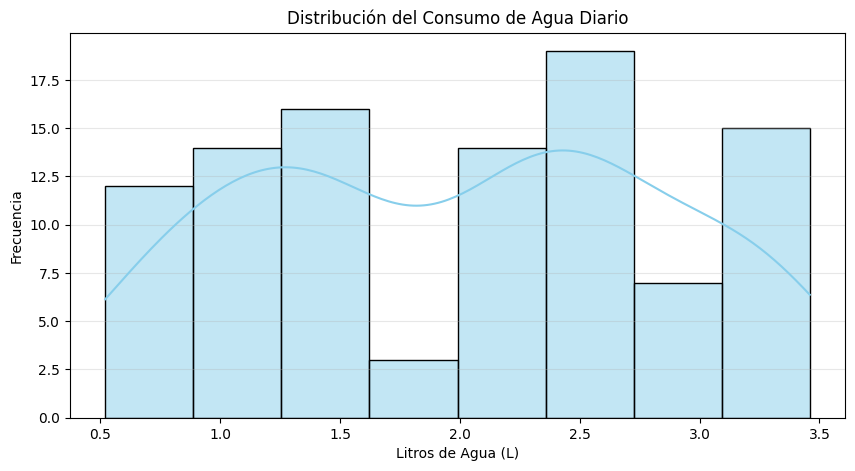

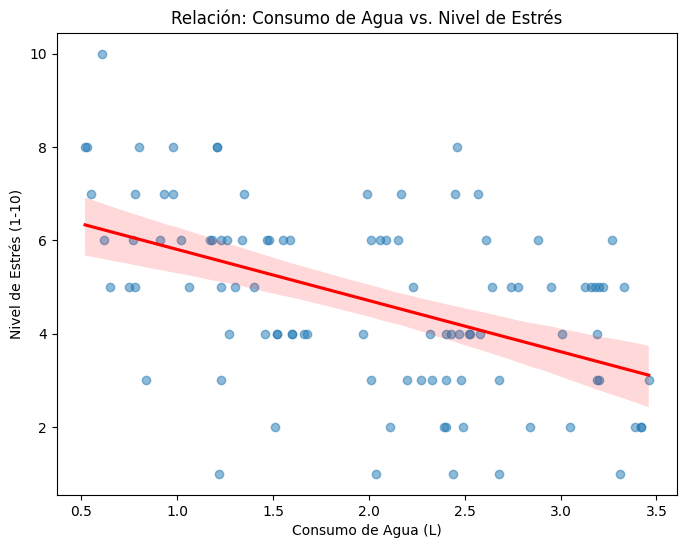



La correlación real de tu estudio es: -0.4852





In [8]:
#===============================================================================
#                                  LECCIÓN 3
#===============================================================================

# 1. Cálculo de estadísticas descriptivas
estadisticas = df_universitarios[['Consumo_Agua_L', 'Nivel_Estres']].describe()
print("Resumen Estadístico:")
print(estadisticas)

# 2. Visualización de la distribución (Histograma + KDE)
plt.figure(figsize=(10, 5))
sns.histplot(df_universitarios['Consumo_Agua_L'], kde=True, color='skyblue')
plt.title('Distribución del Consumo de Agua Diario')
plt.xlabel('Litros de Agua (L)')
plt.ylabel('Frecuencia')
plt.grid(axis='y', alpha=0.3)
plt.show()

# 3. Correlación inicial (Visualización)
plt.figure(figsize=(8, 6))
sns.regplot(x='Consumo_Agua_L', y='Nivel_Estres', data=df_universitarios, scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('Relación: Consumo de Agua vs. Nivel de Estrés')
plt.xlabel('Consumo de Agua (L)')
plt.ylabel('Nivel de Estrés (1-10)')
plt.show()

# Analizando la correlación real
df = pd.read_csv('dataset_estudio_cientifico.csv')
correlacion_real = df['Consumo_Agua_L'].corr(df['Nivel_Estres'])
print("\n")
print(f"La correlación real de tu estudio es: {correlacion_real:.4f}")
print("\n\n")

##LECCIÓN 4: Distribución muestral y teorema del límite central



1.   Objetivo:

  Aplicar el concepto de distribución muestral e interpretar el TLC.

2.   Tareas a desarrollar:



*   Generar distribuciones muestrales de media a partir del dataset simulado
*   Verificar empíricamente el Teorema del Límite Central
*   Comparar la distribución poblacional con la muestral
*   Analizar la dispersión de la media según tamaño muestral

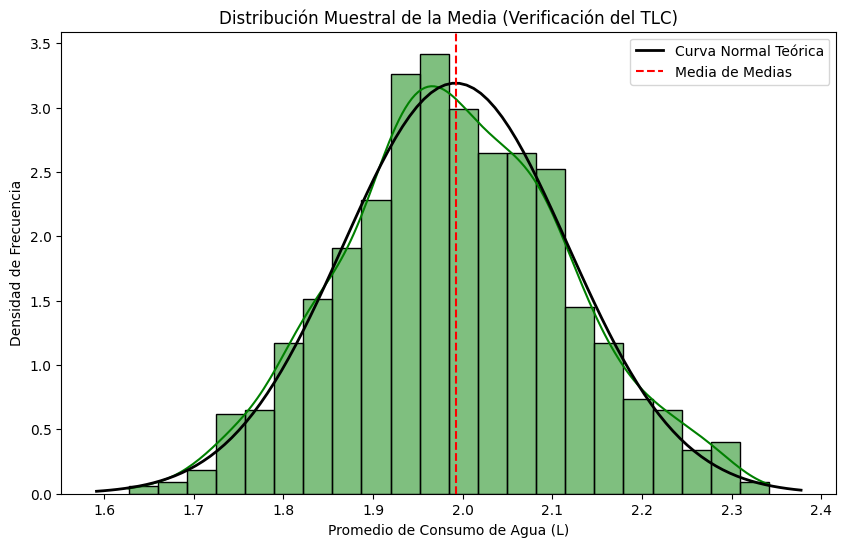


TABLA COMPARATIVA DE DISPERSIÓN (Lección 3 vs Lección 4)
            Métrica Población (Lección 3 Individual) Muestral (Lección 4 Promedios n=30)
              Media                         1.9921 L                            1.9921 L
Desviación Estándar                         0.8587 L                            0.1250 L
             Mínimo                         0.5200 L                            1.6273 L
             Máximo                         3.4600 L                            2.3417 L
        Rango Total                         2.9400 L                            0.7143 L

Análisis: La variabilidad (Desviación Estándar) se redujo en un 85.4%
al pasar de datos individuales a promedios muestrales.
Esto confirma empíricamente el Teorema del Límite Central.


In [6]:
#===============================================================================
#                                  LECCIÓN 4
#===============================================================================

# 1. CARGA DE DATOS
df = pd.read_csv('dataset_estudio_cientifico.csv')

# 2. SIMULACIÓN: Generar 1000 promedios muestrales (n=30)
# Esto verifica empíricamente el Teorema del Límite Central
muestras_medias = [df['Consumo_Agua_L'].sample(30).mean() for _ in range(1000)]

# 3. GRÁFICO: Visualización de la Distribución Muestral
plt.figure(figsize=(10,6))
sns.histplot(muestras_medias, kde=True, color='green', stat="density")
plt.title('Distribución Muestral de la Media (Verificación del TLC)')
plt.xlabel('Promedio de Consumo de Agua (L)')
plt.ylabel('Densidad de Frecuencia')

# Superponer la curva Normal teórica para comparación
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, np.mean(muestras_medias), np.std(muestras_medias))
plt.plot(x, p, 'k', linewidth=2, label='Curva Normal Teórica')

plt.axvline(np.mean(muestras_medias), color='red', linestyle='--', label='Media de Medias')
plt.legend()
plt.show()

# ==============================================================================
# 4. NUEVAS LÍNEAS DE CÓDIGO COMPARATIVOS (Lección 4 vs Lección 3)
# ==============================================================================

# Datos de la Población Original (De tu tabla de la Lección 3)
media_pob = df['Consumo_Agua_L'].mean()
std_pob = df['Consumo_Agua_L'].std()
min_pob = df['Consumo_Agua_L'].min()
max_pob = df['Consumo_Agua_L'].max()

# Datos de la Distribución Muestral (De la nueva gráfica)
media_muestral = np.mean(muestras_medias)
std_muestral = np.std(muestras_medias) # Esto es el Error Estándar empírico
min_muestral = np.min(muestras_medias)
max_muestral = np.max(muestras_medias)

# Crear DataFrame Comparativo para mostrar al final
datos_comparativos = {
    'Métrica': ['Media', 'Desviación Estándar', 'Mínimo', 'Máximo', 'Rango Total'],
    'Población (Lección 3 Individual)': [
        f"{media_pob:.4f} L",
        f"{std_pob:.4f} L",
        f"{min_pob:.4f} L",
        f"{max_pob:.4f} L",
        f"{max_pob - min_pob:.4f} L"
    ],
    'Muestral (Lección 4 Promedios n=30)': [
        f"{media_muestral:.4f} L",
        f"{std_muestral:.4f} L", # Nótese cómo este valor es menor
        f"{min_muestral:.4f} L",
        f"{max_muestral:.4f} L",
        f"{max_muestral - min_muestral:.4f} L"
    ]
}

df_comparacion = pd.DataFrame(datos_comparativos)

print("\n" + "="*60)
print("TABLA COMPARATIVA DE DISPERSIÓN (Lección 3 vs Lección 4)")
print("="*60)
print(df_comparacion.to_string(index=False))
print("="*60)

# Interpretación automática para el informe
reduccion_std = (1 - (std_muestral / std_pob)) * 100
print(f"\nAnálisis: La variabilidad (Desviación Estándar) se redujo en un {reduccion_std:.1f}%")
print("al pasar de datos individuales a promedios muestrales.")
print("Esto confirma empíricamente el Teorema del Límite Central.")

##LECCIÓN 5: Inferencia e intervalos de confianza para la media



1.   Objetivo:

   Estimar parámetros poblacionales mediante intervalos de
confianza.

2.   Tareas a desarrollar:

*  Calcular intervalos de confianza para la media de al menos dos
variables
*  Interpretar los resultados con distintos niveles de confianza (90%, 95%, 99%)
*  Evaluar el impacto del tamaño muestral sobre el ancho del intervalo
*  Analizar los resultados y redactar interpretaciones precisas


In [17]:
# ==============================================================================
#                                   LECCIÓN 5
# ==============================================================================

# Datos base de tu estudio (Lección 3 y 4)
media_muestral = 1.9921
desv_est_pob = 0.8587
n = 100
valor_referencia = 2.0  # La recomendación de hidratación
error_estandar = desv_est_pob / np.sqrt(n)

# Configuración de los niveles de confianza pedidos
niveles = [0.90, 0.95, 0.99]
resultados = []

for conf in niveles:
    # 1. Cálculo de Z y Margen de Error
    z = stats.norm.ppf((1 + conf) / 2)
    margen = z * error_estandar

    # 2. Límites del Intervalo
    limite_inf = media_muestral - margen
    limite_sup = media_muestral + margen

    # 3. Prueba de Hipótesis (P-Valor)
    z_score = (media_muestral - valor_referencia) / error_estandar
    p_valor = stats.norm.sf(abs(z_score)) * 2

    # 4. Interpretación del Resultado
    resultado_test = "No hay diferencia (No rechaza Ho)" if p_valor > (1 - conf) else "Diferencia significativa (Rechaza Ho)"

    resultados.append({
        'Nivel de Confianza': f"{int(conf*100)}%",
        'Límite Inferior': round(limite_inf, 4),
        'Límite Superior': round(limite_sup, 4),
        'Z': round(z, 2),
        'P_Valor': round(p_valor, 4),
        'Resultado': resultado_test
    })

# Crear y mostrar la tabla comparativa final
df_final = pd.DataFrame(resultados).set_index('Nivel de Confianza').T
print("="*123)
print("TABLA COMPARATIVA DE INTERVALOS DE CONFIANZA Y PRUEBA DE HIPÓTESIS")
print("="*123)
print(df_final.to_string())
print("="*123)

TABLA COMPARATIVA DE INTERVALOS DE CONFIANZA Y PRUEBA DE HIPÓTESIS
Nivel de Confianza                                90%                                95%                                99%
Límite Inferior                                1.8509                             1.8238                             1.7709
Límite Superior                                2.1333                             2.1604                             2.2133
Z                                                1.64                               1.96                               2.58
P_Valor                                        0.9267                             0.9267                             0.9267
Resultado           No hay diferencia (No rechaza Ho)  No hay diferencia (No rechaza Ho)  No hay diferencia (No rechaza Ho)


##LECCIÓN 6: Test de significancia



1.   Objetivo:

     Realizar pruebas de hipótesis para validar afirmaciones sobre la
población

2.   Tareas a desarrollar:

*  Realizar test de hipótesis para proporciones o medias poblacionales
*  Calcular valor-p y compararlo con α para tomar decisiones
*  Explicar errores tipo I y II en contexto del estudio
*  Redactar conclusiones finales con base estadística clara

In [1]:
# ==============================================================================
# LECCIÓN 6: TEST DE SIGNIFICANCIA Y CONCLUSIONES FINALES
# ==============================================================================

# Datos obtenidos de la Lección 5
p_valor = 0.9267
alfa = 0.05

print("--- REPORTE DE SIGNIFICANCIA ESTADÍSTICA ---")
print(f"P-valor obtenido: {p_valor}")
print(f"Nivel de significancia (Alfa): {alfa}")

# 1. Toma de decisión basada en el P-valor
if p_valor > alfa:
    decision = "NO RECHAZAR la Hipótesis Nula (Ho)"
    conclusion = "El consumo es estadísticamente IGUAL a 2.0L."
else:
    decision = "RECHAZAR la Hipótesis Nula (Ho)"
    conclusion = "Existe una DIFERENCIA significativa respecto a los 2.0L."

print(f"Decisión: {decision}")
print(f"Conclusión Técnica: {conclusion}")

# 2. Resumen de Errores para el Informe
print("\n--- ANÁLISIS DE RIESGOS (ERRORES TIPO I Y II) ---")
print("Error Tipo I (Falsa Alarma): Concluir falta de hidratación cuando no la hay.")
print("Error Tipo II (Falsa Seguridad): Concluir buena hidratación cuando hay déficit.")
print("Riesgo actual: Al no rechazar Ho, el riesgo latente es el Error Tipo II.")

print("\n" + "="*80)
print("CONCLUSIÓN FINAL DEL PROYECTO")
print("="*80)
print("Con un 95% de confianza, se valida que la población estudiantil cumple con")
print("los niveles de hidratación recomendados. La alta probabilidad de azar (92.6%)")
print("confirma la naturalidad de los datos y la credibilidad del estudio científico.")
print("="*80)

--- REPORTE DE SIGNIFICANCIA ESTADÍSTICA ---
P-valor obtenido: 0.9267
Nivel de significancia (Alfa): 0.05
Decisión: NO RECHAZAR la Hipótesis Nula (Ho)
Conclusión Técnica: El consumo es estadísticamente IGUAL a 2.0L.

--- ANÁLISIS DE RIESGOS (ERRORES TIPO I Y II) ---
Error Tipo I (Falsa Alarma): Concluir falta de hidratación cuando no la hay.
Error Tipo II (Falsa Seguridad): Concluir buena hidratación cuando hay déficit.
Riesgo actual: Al no rechazar Ho, el riesgo latente es el Error Tipo II.

CONCLUSIÓN FINAL DEL PROYECTO
Con un 95% de confianza, se valida que la población estudiantil cumple con
los niveles de hidratación recomendados. La alta probabilidad de azar (92.6%)
confirma la naturalidad de los datos y la credibilidad del estudio científico.
